In [1]:
# import dependencies

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import product
from scipy.stats  import norm, pointbiserialr
from scipy.integrate import trapezoid
from scipy.special import expit
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


# **Models**

# Logistic Regression

In [2]:
class LogRegression():
    def __init__(self, alpha=0.001, lambda_reg=0, penalty = 'L2', epochs=1000, max_iter=10, early_stopping=False, verbose=False):
        self.alpha = alpha # learning rate
        self.lambda_reg = lambda_reg # regularization parameter
        self.penalty = penalty # type of penalty
        self.epochs = epochs # number of gradient descent iterations
        self.max_iter = max_iter # max iterations for early stopping
        self.early_stopping = early_stopping

        # model parameters
        self.w = None # weight
        self.b = None # bias
        self.y_pred = None
        self.loss_history = []
        self.verbose = verbose

        # model metrics
        self.standard_errors = None
        self.z_scores = None
        self.p_values = None
        self.aic = None

    # sigmoid function applied to get either values between 0 and 1
    def sigmoid(self, x):
      return expit(x)

    # log loss function
    def loss(self, y_true, y_pred):
      y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # 0 = 1e-15, 1 = 0.999 to avoid log(0)
      loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
      l1 = 0
      l2=0
      if self.lambda_reg > 0:
        l1 = np.sum(np.abs(self.w))
        l2 = np.dot(self.w, self.w)
      if self.penalty == 'L2':
        loss += 0.5* self.lambda_reg*l2
      elif self.penalty == 'L1':
        loss += self.lambda_reg*l1
      elif self.penalty == 'elasticnet':
        loss +=  self.lambda_reg*self.alpha*l1 + 0.5*(1-self.alpha)*l2
      else:
        raise ValueError("Penalty must be 'L1', 'L2' or 'elasticnet'")
      return loss

    def gradient(self, X_train, Y_train, y_pred):
      n = len(Y_train)
      gradient_w = X_train.T @ (y_pred - Y_train) / n
      gradient_b = np.mean(y_pred - Y_train)
      if self.lambda_reg >0:
        if self.penalty == 'L1':
          gradient_w += self.lambda_reg * np.sign(self.w)
        elif self.penalty == 'L2':
          gradient_w += self.lambda_reg * self.w
        elif self.penalty == 'elasticnet':
          gradient_w += self.lambda_reg * (self.alpha * np.sign(self.w) +
                          (1-self.alpha) * self.w)
      return gradient_w, gradient_b

    def fit(self, X_train, Y_train):
        if len(X_train) != len(Y_train):
          raise ValueError("The length of X and Y does not correspond.")

        shuffling = np.random.permutation(len(X_train))
        # X_train can be accepted only as a numpy array
        X_train = X_train[shuffling] # shuffle the data

        # Y_train can be accepted either as pandas df, either as numpy array
        if hasattr(Y_train, 'iloc'):
          Y_train = Y_train.iloc[shuffling].values
        else:
          Y_train = Y_train[shuffling]
        # if early stopping = True, we create the validation set to evaluate the performance
        if self.early_stopping:
          val_size = 0.2
          rows = int(val_size * len(X_train))
          X_val, Y_val = X_train[:rows], Y_train[:rows]
          X_train, Y_train = X_train[rows:], Y_train[rows:]
          if self.verbose:
            print(f"Training set on {len(X_train)} observations.")
            print(f"Validation set: {len(X_val)}")
        else:
          X_val, Y_val = None, None
          if self.verbose:
            print(f"Training on full dataset: {len(X_train)} observations.")
        # initialization of the variables
        self.w = np.zeros(X_train.shape[1])
        self.b=0.0
        best_w = self.w.copy()
        best_b = self.b
        best_loss = float('inf')
        counter = 0
        if self.verbose:
          print(f"Parameters: weights {self.w.shape}, bias {self.b}")
          print(f"Learning rate: {self.alpha}, lambda: {self.lambda_reg}, type of regularization: {self.penalty}")

        for epoch in range(self.epochs):
          p = X_train @ self.w + self.b
          y_pred = self.sigmoid(p)
          gradient_w, gradient_b = self.gradient(X_train, Y_train, y_pred)
          self.w -= self.alpha * gradient_w
          self.b -= self.alpha * gradient_b
          train_loss = self.loss(Y_train, y_pred)
          if self.verbose:
            print(f"Weights: {self.w}")
            print(f"Bias: {self.b}")
            print(f"train loss: {train_loss}")

          if self.early_stopping:
            val_loss = self.loss(Y_val, self.sigmoid(X_val @self.w + self.b))
            if val_loss < best_loss:
              best_loss = val_loss
              best_w = self.w.copy()
              best_b = self.b
              counter = 0
            else:
              counter +=1
              if counter >= self.max_iter:
                self.w, self.b = best_w, best_b
                break
          else:
            if train_loss < best_loss:
              best_loss = train_loss
              best_w = self.w.copy()
              best_b = self.b
        # if early stopping = False, we save the last parameters (optimized through gradient desc)
        # if early stopping = True, the parameters are the best ones based on the val set performance
        self.w, self.b = best_w, best_b
        self.y_pred = self.sigmoid(X_train @ self.w+self.b)
        if self.verbose:
          print(f"Final training loss: {best_loss:.4f}")

        # SE, z, p-value, AIC
        try:
          W = np.diag(self.y_pred * (1 - self.y_pred))
          # adding a column with ones in order to have the intercept in the summary
          X_withones = np.column_stack([np.ones(len(Y_train)), X_train])
          Hessian = X_withones.T @ W @ X_withones #X transposed * W * X

          epsilon = 1e-6 * np.eye(Hessian.shape[0]) # adding a small value to guarantee invertibility
          Hessian += epsilon
          Cov_matrix = np.linalg.inv(Hessian)  # Cov matrix= inverse of the Hessian
          self.standard_errors = np.sqrt(np.diagonal(Cov_matrix)) # sqrt of the diagonal elements

          self.z_scores = np.concatenate([[self.b], self.w]) / self.standard_errors
          self.p_values = 2 * (1 - norm.cdf(np.abs(self.z_scores)))

        except Exception as e:
            print(f"Error: {e}")
        log_loss = self.loss(Y_train, self.y_pred)
        k = len(self.w) + 1 # number of features + intercept for model complexity
        self.aic = 2*k-2*len(Y_train)*log_loss

    # formatting function for the output: all floats must have 4 decimals
    def safe_format(self,value):
      if isinstance(value, (float, int)) and not np.isnan(value):
        return f"{value:.4f}"
      else:
        return "NaN"
    # R algorithm type of summary
    def summary(self, features_names = None):
      print("Summary:")
      print("="*60)
      if np.isnan(self.b):
        formatted = "NaN"
      else:
        formatted = f"{self.b:.4f}"

      if features_names is None:
        features_names = [f'X{i+1}' for i in range(len(self.w))]
      elif len(features_names) != len(self.w):
        raise ValueError('Using default names.')
        features_names = [f'X{i+1}' for i in range(len(self.w))]

      #results table
      print(f"{'Coefficients':<15} {'Estimate':>12} {'Std. Error':>12} {'|z|':>12} {'Pr(>|z|)':>12}")
      print("="*60)
      print(f"{'Intercept':<15}"
          f"{self.b:>12.4f}"
          f"{self.safe_format(self.standard_errors[0]):>12}"
          f"{self.safe_format(self.z_scores[0]):>12}"
          f"{self.safe_format(self.p_values[0]):>12}")

      for i, (coeff, std, z, p) in enumerate(zip(self.w, self.standard_errors[1:], self.z_scores[1:], self.p_values[1:])):
        print(f"{features_names[i]:<15}"
              f"{coeff:>12.4f}"
              f"{self.safe_format(std):>12}"
              f"{self.safe_format(z):>12}"
              f"{self.safe_format(p):>12}")
      # aic
      print("-"*60)
      print(f"{'AIC':<15}{self.aic:>12.4f}")

    def predict(self, X_test, threshold = 0.5):
      # predictions is done with the values of w and b that we found by training the model
      p_test = X_test @ self.w + self.b
      y_pred_test = self.sigmoid(p_test)
      return y_pred_test # return probabilities



#Support Vector Machine

In [28]:

class SupportVectorMachine:
  def __init__(self, C=1, kernel = 'linear', probability = True, gamma='scale', d= 1, r=1, epochs = 1000, max_iter = 100, early_stopping =False, verbose = False):
    self.C = float(C)
    self.lambda_reg = 1.0 / self.C if C >0 else 0 # regularization parameter (1/C)
    self.kernel = kernel # polynomial or radial
    self.probability = probability
    self.gamma = gamma # gamma parameter for polynomial and radial kernel
    self.d = d # degree of the polynomial kernel
    self.r = r # constant parameter for the polynomial kernel
    self.early_stopping=early_stopping
    self.epochs = epochs
    self.max_iter = max_iter # patience for early stopping
    self.verbose = verbose

    #model parameters
    self.w = None # weights
    self.b = None # bias
    self.multipliers = None # Langrange multipliers
    self._gamma = None
    self.support_vectors = None
    self.support_vectors_labels =None
    self.support_vectors_indices=None

    # training information
    self.loss_history = []
    self.val_loss_history = []
    self.best_params=None

  # sigmoid function to get values between 0 and 1
  def sigmoid(self, x):
    return expit(x)

  # gamma parameter for polynomial and radial kernels
  def create_gamma(self, X_train):
    if self.kernel in ['polynomial', 'radial'] and isinstance(self.gamma, str):
      if self.gamma == 'scale':
        var = np.var(X_train, axis = 0)
        self._gamma = 1.0 / (X_train.shape[1] * np.sqrt(var.mean())) if var.mean() !=0 else 1.0
      elif self.gamma == 'auto':
        self._gamma = 1.0/ X_train.shape[1]
      else:
        raise ValueError('Gamma must be auto or scale.')
    elif isinstance(self.gamma, (int, float)):
      self._gamma = self.gamma

  def kernel_matrix(self, X1, X2=None):
    if X2 is None:
    #self kernel matrix
      X2 = X1
    if self.kernel == 'polynomial':
        K = np.dot(X1, X2.T)
        return (self._gamma * K + self.r) ** self.d
    elif self.kernel == 'radial':
        X1_norm = np.sum(X1**2, axis=1)[:, np.newaxis] #reshaped in (N1, 1)
        X2_norm = np.sum(X2**2, axis=1)[np.newaxis, :] #rehsaped in (1, N2)
        K = X1_norm + X2_norm - 2 * np.dot(X1, X2.T) #squared Euclidean distance matrix
        return np.exp(-self._gamma * K)
    else:
        raise ValueError("Kernel not supported")
  #loss
  def linear_hinge_loss(self, X_train, Y_train):
    margins = Y_train * (np.dot(X_train, self.w) + self.b)
    loss = np.mean(np.maximum(0, 1-margins)) # hinge loss
    if self.lambda_reg >0:
      loss += (self.lambda_reg/2)* np.dot(self.w, self.w) #l2 regularization
    return loss

  #loss
  def kernel_hinge_loss(self, X_train, Y_train, K = None):
    decision_values = np.dot(K, self.multipliers)
    margins=Y_train * decision_values
    hinge_loss = np.mean(np.maximum(0, 1-margins))
    if self.lambda_reg > 0:
      reg_term = 0.5 * self.lambda_reg * np.dot(self.multipliers, np.dot(K, self.multipliers))
      hinge_loss += reg_term
    return hinge_loss

  # linear PEGASOS udpate
  def linear_PEGASOS(self, X_train, Y_train, t):
    # linear support vector machine
    index = np.random.randint(0, len(Y_train))
    xt, yt = X_train[index], Y_train[index]
    margin = yt * (np.dot(self.w, xt)+self.b)
    eta_t = 1.0/ (self.lambda_reg *t) if self.lambda_reg >0 else 1.0/t # learning rate
    if margin < 1:
      if self.lambda_reg>0:
        self.w = (1-eta_t * self.lambda_reg) * self.w + eta_t *yt*xt
      else: # no regularization
        self.w += eta_t * yt*xt
      self.b += eta_t*yt
    else:
      if self.lambda_reg>0:
        self.w = (1-eta_t*self.lambda_reg)*self.w
    return self.w, self.b

  def kernel_PEGASOS(self, X_train, Y_train, K, t):
    index = np.random.randint(0, len(Y_train))
    margin = Y_train[index] * (np.dot(K[:,index], self.multipliers))
    eta_t = 1.0/ (self.lambda_reg *t) if self.lambda_reg >0 else 1.0/t # learning rate
    if margin < 1:
      if self.lambda_reg>0:
        self.multipliers = (1-eta_t * self.lambda_reg) * self.multipliers
        self.multipliers[index] += eta_t*Y_train[index]
      else:
        self.multipliers[index] += eta_t *Y_train[index]
    else:
      if self.lambda_reg>0:
        self.multipliers = (1-eta_t*self.lambda_reg)*self.multipliers
    return self.multipliers

  def fit(self, X_train, Y_train):
    if len(X_train) != len(Y_train):
      raise ValueError("The length of X and Y does not correspond.") # debugging

    # automatically convert the binary outcome [0,1] in [-1, 1]
    Y_train = np.where(Y_train == 0, -1, 1)
    shuffling = np.random.permutation(len(X_train))
    X_train = X_train[shuffling]
    Y_train = Y_train[shuffling]
    # initialize gamma if using kernels
    if self.kernel in ['polynomial', 'radial']:
      self.create_gamma(X_train)
    if self.early_stopping:
      val_size = 0.2
      rows = int(val_size * len(X_train))
      # split dataset into X_train and X_val for optimization
      X_val, Y_val = X_train[:rows], Y_train[:rows]
      X_train, Y_train = X_train[rows:], Y_train[rows:]
      if self.kernel != 'linear':
        K_train = self.kernel_matrix(X_train)
        K_val = self.kernel_matrix(X_val)
    else:
      X_train, Y_train = X_train, Y_train
      X_val, Y_val = None, None
    #parameters
    if self.kernel == 'linear':
      self.w = np.zeros(X_train.shape[1])
      self.b = 0.0
      self.multipliers = None
    else:
      self.w = None
      self.b = 0.0
      self.multipliers = np.random.uniform(0, 1, size=len(X_train))
      if not self.early_stopping:
        K_train = self.kernel_matrix(X_train)
        K_val = None
    best_loss = float('inf')
    improvements = 0
    self.best_params = None

    for t in range(1, self.epochs + 1): # to avoid t = 0 since it is a term of fraction
      if self.kernel == 'linear':
        self.w, self.b = self.linear_PEGASOS(X_train, Y_train, t)
      elif self.kernel in ['polynomial', 'radial']:
        self.kernel_PEGASOS(X_train, Y_train, K_train, t)
      if self.verbose and t % 100 == 0:
        if self.kernel == 'linear':
          loss = self.linear_hinge_loss(X_train, Y_train)
        else:
          loss = self.kernel_hinge_loss(X_train, Y_train, K_train)
        self.loss_history.append(loss)
        print(f"Iteration: {t}, loss: {loss:.4f}")
        val_loss = None
        if self.early_stopping:
          if self.kernel == 'linear':
            val_loss = self.linear_hinge_loss(X_val, Y_val)
          else:
            val_loss = self.kernel_hinge_loss(X_val, Y_val, K_val)
          self.val_loss_history.append(val_loss)
          if val_loss < best_loss:
            best_loss = val_loss
            improvements= 0
            self.best_params = {'w':self.w.copy() if self.kernel == 'linear' else None,
                                'b': self.b.copy(),
                                'multipliers': self.multipliers.copy() if self.kernel != 'linear' else None}

          else:
            improvements+=1
            if improvements >= self.max_iter:
              if self.verbose:
                print(f"Early stopping at iteration {t}.")
              break
        if self.verbose:
          log_msg = f"Iteration {t}: Train Loss = {loss:.4f}"
          if val_loss is not None:
              log_msg += f", Val Loss = {val_loss:.4f}"
          print(log_msg)
    if self.early_stopping and self.best_params is not None:
      if self.kernel == 'linear':
        self.w = self.best_params['w']
      else:
        self.multipliers = self.best_params['multipliers']
      self.b = self.best_params['b']

    #support vectors
    if self.kernel == 'linear':
      margins = Y_train * (np.dot(X_train, self.w) + self.b)
      self.support_vectors = X_train[margins <= 1 + 1e-5]
    else:
    # For kernel SVM, support vectors are points with alpha > 0
      sv_indices = self.multipliers > 1e-5
      self.support_vectors = X_train[sv_indices]
      self.support_vectors_labels = Y_train[sv_indices]
      self.multipliers = self.multipliers[sv_indices]

  # R algorithm type of summary
  def summary(self):
    """Print model summary."""
    print("SVM Model Summary:")
    print("----------------------------------------")
    print(f"Kernel: {self.kernel}")
    print(f"Regularization parameter (C): {self.C:.4f}")

    if self.kernel in ['polynomial', 'radial']:
      print(f"Gamma: {self._gamma:.4f}")
    if self.kernel == 'polynomial':
      print(f"Degree: {self.d}")
      print(f"Coefficient: {self.r}")

    if self.support_vectors is not None:
      print(f"Number of support vectors: {len(self.support_vectors)}")

    if self.kernel == 'linear' and self.w is not None:
      print(f"Weight vector shape: {self.w.shape}")

    print(f"Bias term: {self.b:.4f}")
    print("----------------------------------------")

  def predict(self, X_test):
    if self.kernel == 'linear':
      if self.w is None:
        raise ValueError("Model not trained yet. Call fit() first.")
      if self.probability:
        raw= np.dot(X_test, self.w) + self.b
        probabilities = self.sigmoid(raw)
        return probabilities
      else:
        return np.where(np.dot(X_test, self.w) + self.b >= 0, 1, -1)
    else:
      if self.support_vectors is None or self.multipliers is None:
        raise ValueError("Model not trained yet. Call fit() first.")
      # Compute kernel between test points and support vectors
      K_test = self.kernel_matrix(X_test, self.support_vectors)
      if self.probability:
        raw = K_test.dot(self.multipliers * self.support_vectors_labels)
        probabilities = self.sigmoid(raw)
        return probabilities
      else:
        return np.where(K_test.dot(self.multipliers * self.support_vectors_labels) >= 0, 1, -1)

# **Evaluation Metrics**

In [4]:
class Metrics():
  def __init__(self, y_true, y_pred, threshold = 0.5):
    self.threshold = threshold
    self.y_pred = y_pred
    self.y_true = np.array(y_true)
    self.y_binarypred = self.binary_ypred(y_pred)
    self.__init_metrics()

  # convert output into a binary predictions for acc_score and conf_matrix
  def binary_ypred(self, y_pred):
    if np.all((y_pred >=0) & (y_pred <= 1)):
      return (y_pred >= self.threshold).astype(int)

  def __init_metrics(self):
    self.precision = None
    self.recall = None
    self.specificity = None
    self.F1_score = None
    self.roc_curve = None
    self.auc = None

  def acc_score(self):
    return np.mean(self.y_true == self.y_binarypred)

  def conf_matrix(self):
    true_positives = np.sum((self.y_true == 1) & (self.y_binarypred == 1))
    true_negatives = np.sum((self.y_true == 0) & (self.y_binarypred == 0))
    false_positives = np.sum((self.y_true == 0) & (self.y_binarypred == 1))
    false_negatives = np.sum((self.y_true == 1) & (self.y_binarypred == 0))
    self.precision = true_positives / (true_positives + false_positives) if true_positives + false_positives > 0 else 0
    self.recall = true_positives / (true_positives + false_negatives) if true_positives + false_negatives > 0 else 0
    self.specificity = true_negatives / (true_negatives + false_positives) if true_negatives + false_positives > 0 else 0
    self.F1_score = 2 * (self.precision * self.recall) / (self.precision + self.recall) if self.precision + self.recall > 0 else 0

    result = (
          f"Precision: {self.precision:.4f}, "
          f"Recall: {self.recall:.4f}, "
          f"Specificity: {self.specificity:.4f}, "
          f"F1 score: {self.F1_score:.4f}\n"
          f"Confusion Matrix: \n "
          f"TP: {true_positives},\n "
          f"TN: {true_negatives},\n "
          f"FP: {false_positives},\n "
          f"FN: {false_negatives}"
      )

    return result

  def roc(self):
    thresholds = np.linspace(1, 0, 100)
    true_pos_rate = []
    false_pos_rate = []
    for thresh in thresholds:
      y_pred_thresh = (self.y_pred>= thresh).astype(int)

      true_positives = np.sum((self.y_true == 1) & (y_pred_thresh == 1))
      true_negatives = np.sum((self.y_true == 0) & (y_pred_thresh == 0))
      false_positives = np.sum((self.y_true == 0) & (y_pred_thresh == 1))
      false_negatives = np.sum((self.y_true == 1) & (y_pred_thresh == 0))

      true_pos_rate.append(true_positives / (true_positives + false_negatives)  if (true_positives + false_negatives) > 0 else 0)
      false_pos_rate.append(false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0)
    #integrate true positive rate and false positive rate to get the area under the curve
    self.auc = np.trapezoid(true_pos_rate, false_pos_rate)
    self.roc_curve = (false_pos_rate, true_pos_rate, thresholds)

    return f"AUC: {self.auc:.4f}"

  def plot_roc(self):
    if self.roc_curve is None:
      self.roc() # compute ROC curve
    false_pos_rate, true_pos_rate, thresholds = self.roc_curve
    plt.figure(figsize = (8,6))
    plt.plot(self.roc_curve[0], self.roc_curve[1], label=f'ROC curve (AUC = {self.auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier') #draw a diagonal line

    # find the optimal threshold
    current_idx = np.argmin(np.abs(np.array(thresholds) - self.threshold))
    plt.scatter(false_pos_rate[current_idx], true_pos_rate[current_idx],
              color='red', label=f'Current threshold ({self.threshold:.2f})')

    optimal_idx = np.argmin((np.array(false_pos_rate)**2 + (np.array(true_pos_rate)-1)**2))
    plt.scatter(false_pos_rate[optimal_idx], true_pos_rate[optimal_idx],
              color='green', label=f'Optimal threshold ({thresholds[optimal_idx]:.2f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()






# **Hyperparameters tuning**

In [5]:
def CrossValidation(X_train, Y_train, model, k =5, random_state = None):
  sorted_indices = np.argsort(Y_train)
  # number of element for each class
  unique_classes, class_counts = np.unique(Y_train, return_counts = True)
  # list that defines where the indices of a class start and end
  class_start_indices = np.cumsum([0]+class_counts.tolist())
  accuracy_scores=[]
  for fold in range(k):
    train_indices, val_indices = [], []
    for i, cls in enumerate(unique_classes):
      start_idx = class_start_indices[i]
      end_idx = class_start_indices[i + 1]
      cls_indices = np.arange(start_idx, end_idx)
      np.random.seed(random_state + fold if random_state is not None else None)
      np.random.shuffle(cls_indices)

      fold_size = len(cls_indices) // k
      val_start = fold * fold_size
      val_end = (fold + 1) * fold_size if fold != k - 1 else len(cls_indices)
      val_indices.extend(sorted_indices[cls_indices[val_start:val_end]])
      train_indices.extend(sorted_indices[np.concatenate([
          cls_indices[:val_start], cls_indices[val_end:]])])

    np.random.seed(random_state)
    np.random.shuffle(train_indices)
    np.random.shuffle(val_indices)
    X_train_cv, X_val = X_train[train_indices], X_train[val_indices]
    Y_train_cv, Y_val = Y_train[train_indices], Y_train[val_indices]
    # model training
    model_copy = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    model_copy.fit(X_train_cv, Y_train_cv)
    y_pred = model_copy.predict(X_val)
    metrics = Metrics(Y_val, y_pred)
    accuracy = metrics.acc_score()
    accuracy_scores.append(accuracy)

  return np.mean(accuracy_scores)


def GridSearch(X_train, Y_train, model_class, params_grid = None, cv = 5, random_state = None):
  X_train = np.array(X_train)
  Y_train = np.array(Y_train)
  if params_grid is None:
    params_grid = {}
  best_params = None
  best_model = None
  best_accuracy = 0
  results = []
  # the algorithm must accept a list of dictionaries
  if isinstance(params_grid, list):
    grids = params_grid
  else:
    grids = [params_grid]
  # generate all the combinations of parameters
  for grid in grids:
    keys, values = zip(*grid.items())
    for combination in product(*values):
      current_params = dict(zip(keys, combination))
      model = model_class(**current_params)
      mean_accuracy =CrossValidation(X_train, Y_train, model=model, k = cv, random_state=random_state)
      results.append({'params':current_params, 'accuracy': mean_accuracy})
      # Update the best parameters
      if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = current_params
  best_model = model_class(**best_params)
  return {"Best parameters:":best_params, "Best accuracy:": float(best_accuracy)}



# Dataset and Data Exploration

In [6]:

url = 'https://raw.githubusercontent.com/Valeria-Riccardo/statistical-learning/refs/heads/main/whitewine.csv'
data = pd.read_csv(url, sep=';')
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [7]:
data.shape

(4898, 12)

In [8]:
# convert target variable (quality) into a binary variable
data['quality'] = np.where(data['quality'] > 5, 1, 0)

# spot imbalance between categories
np.unique(data['quality'], return_counts=True)


(array([0, 1]), array([1640, 3258]))

In [9]:
#null values

np.isnan(data).sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


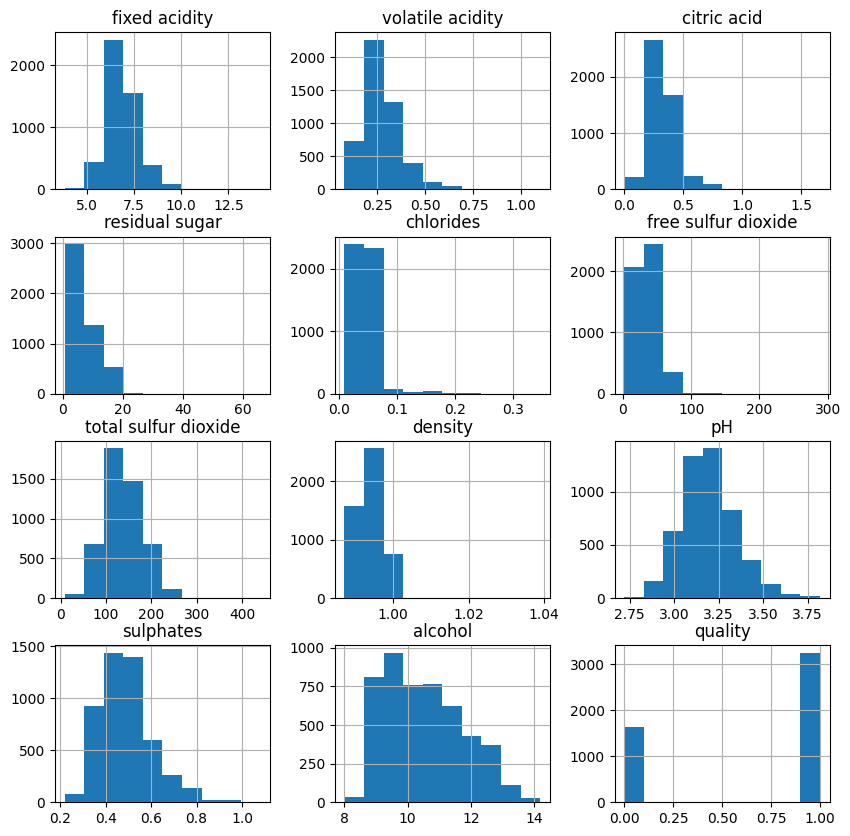

In [10]:
# data distribution

data.hist(figsize = (10,10))
plt.show()

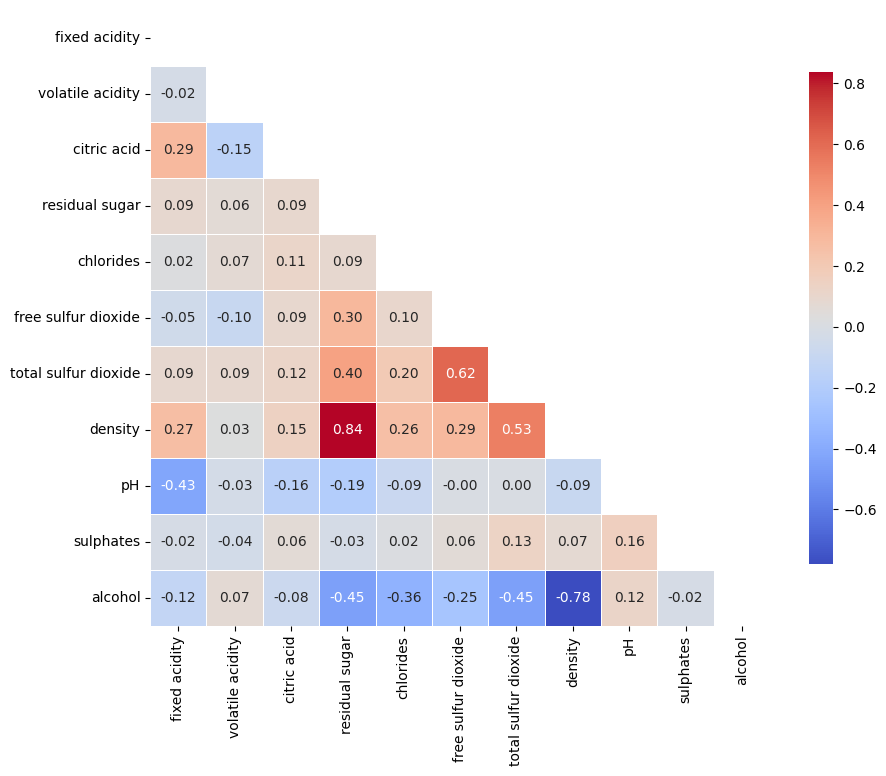

In [11]:
# correlation analysis removing the target variable

corr_data = data.drop(['quality'], axis =1)
corr_data.columns

corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype = bool)) # mask the lower part of the matrix

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5,
            mask = mask, cbar_kws={"shrink": .8})
plt.show()

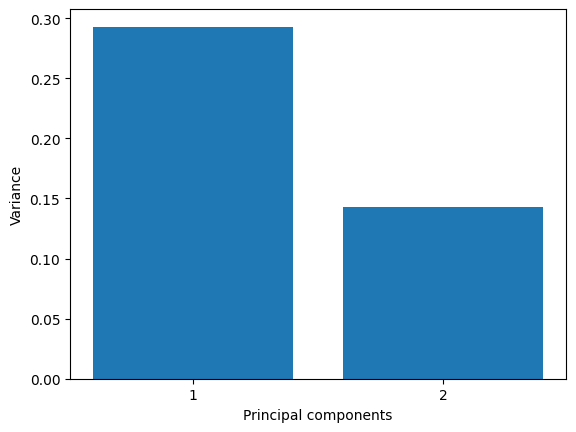

In [12]:
# pca


scale = StandardScaler()
data_scaled = scale.fit_transform(corr_data)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(data_scaled)
principal_comp = pd.DataFrame(pca_results, columns = ['PC1', 'PC2'])

explained_var = pca.explained_variance_ratio_
plt.bar(range(1, len(explained_var)+1), explained_var)
plt.xlabel('Principal components')
plt.ylabel('Variance')
plt.xticks(range(1, len(explained_var)+1))
plt.show()




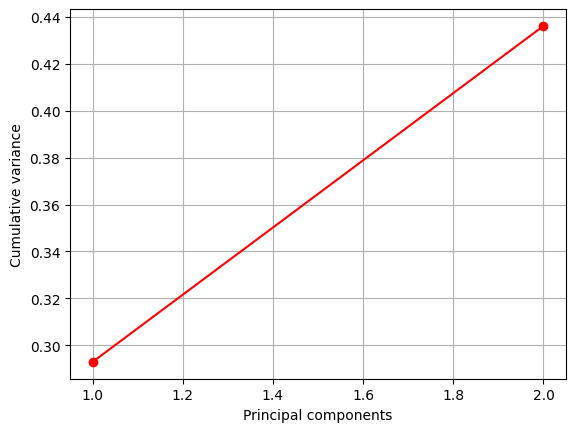

In [13]:
# cumulative variance

cumvar = np.cumsum(explained_var)
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='r')
plt.xlabel('Principal components')
plt.ylabel('Cumulative variance')
plt.grid(True)
plt.show()

In [14]:
# correlation between target binary variable and explanatory variables through Point-Biserial

for col in corr_data.columns:
  corr, p_value = pointbiserialr(data['quality'], corr_data[col])
  print(f"Correlation between quality and {col}: {corr:.4f}, p-value: {p_value:.4f}")

Correlation between quality and fixed acidity: -0.0897, p-value: 0.0000
Correlation between quality and volatile acidity: -0.2254, p-value: 0.0000
Correlation between quality and citric acid: -0.0007, p-value: 0.9609
Correlation between quality and residual sugar: -0.0928, p-value: 0.0000
Correlation between quality and chlorides: -0.1839, p-value: 0.0000
Correlation between quality and free sulfur dioxide: -0.0013, p-value: 0.9287
Correlation between quality and total sulfur dioxide: -0.1709, p-value: 0.0000
Correlation between quality and density: -0.2687, p-value: 0.0000
Correlation between quality and pH: 0.0837, p-value: 0.0000
Correlation between quality and sulphates: 0.0519, p-value: 0.0003
Correlation between quality and alcohol: 0.3833, p-value: 0.0000


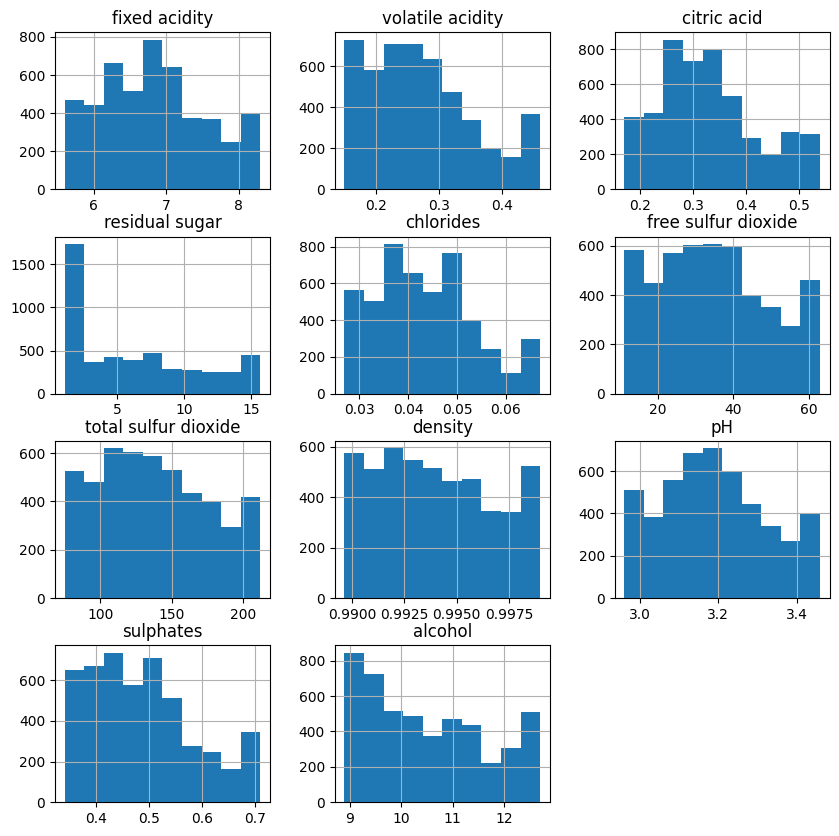

In [15]:
# removal of outliers
data_clean = corr_data.copy()
for col in corr_data:
  winsorized_data = winsorize(corr_data[col], limits=[0.05, 0.05])
  data_clean[col] = winsorized_data
# analysis of the winsorizing effect

data_clean.hist(figsize = (10,10))
plt.show()

# Prediction

**Logistic Regression**

In [16]:
# oversampling

features_names = corr_data.columns.tolist()

array_corrdata = np.array(corr_data)
array_quality = np.array(data['quality'])
unique_classes, class_counts = np.unique(data['quality'], return_counts=True)
majority_class = unique_classes[np.argmax(class_counts)] # class with more observations
minority_class = unique_classes[np.argmin(class_counts)] # class with less observations

# data separation
minority = (data['quality'] == minority_class)
X_minority = array_corrdata[minority]
Y_minority = array_quality[minority]
majority = (data['quality'] == majority_class)
X_majority = array_corrdata[majority]
Y_majority = array_quality[majority]
samples_need = len(X_majority) - len(X_minority) # n of observations required

# select random samples of the minority class

indices_to_duplicate = np.random.choice(len(X_minority), size=samples_need, replace=True)
X_minority_oversampled = X_minority[indices_to_duplicate]
Y_minority_oversampled = Y_minority[indices_to_duplicate]

X_majority_df = pd.DataFrame(X_majority, columns =features_names)
X_minority_original_df = pd.DataFrame(X_minority, columns = features_names)

# combine data
X_array = np.vstack([X_majority, X_minority, X_minority_oversampled])
X_df = pd.DataFrame(X_array, columns = features_names)
Y = np.concatenate([Y_majority, Y_minority, Y_minority_oversampled])

In [17]:

X = scale.fit_transform(X_array)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

In [18]:

lr_parameters = [{ 'alpha': [0.01, 0.1, 0.5],
                  'lambda_reg': [0, 0.01, 0.5],
                  'penalty': ['L1', 'L2', 'elasticnet'],
                  'early_stopping' : [True],
                  'max_iter' : [1000, 5000, 10000]
                  },
                 {'alpha': [0.01, 0.1, 0.5],
                  'lambda_reg': [0, 0.01, 0.5],
                  'penalty': ['L1', 'L2', 'elasticnet'],
                  'early_stopping' : [False],
                 }]
results = GridSearch(X_train, Y_train, model_class = LogRegression, params_grid = lr_parameters)
results

{'Best parameters:': {'alpha': 0.01,
  'lambda_reg': 0,
  'penalty': 'L2',
  'early_stopping': False},
 'Best accuracy:': 0.7300472124782138}

In [25]:

model = LogRegression(alpha = 0.01, lambda_reg = 0,early_stopping = False)
model.fit(X_train, Y_train)
model.summary(features_names = features_names)
pred = model.predict(X_test)
metrics = Metrics(Y_test, pred)
print(f"Accuracy: {metrics.acc_score()}")
print(f"Confusion matrix: {metrics.conf_matrix()}")
print(f"AUC: {metrics.roc()}")


Summary:
Coefficients        Estimate   Std. Error          |z|     Pr(>|z|)
Intercept            0.0024      0.0309      0.0776      0.9381
fixed acidity       -0.0739      0.0562     -1.3152      0.1884
volatile acidity     -0.4499      0.0368    -12.2415      0.0000
citric acid          0.0235      0.0341      0.6890      0.4908
residual sugar       0.2292      0.1247      1.8384      0.0660
chlorides           -0.1704      0.0415     -4.1032      0.0000
free sulfur dioxide      0.2160      0.0431      5.0179      0.0000
total sulfur dioxide     -0.1329      0.0473     -2.8084      0.0050
density             -0.2411      0.1924     -1.2531      0.2102
pH                   0.0564      0.0484      1.1652      0.2439
sulphates            0.1348      0.0339      3.9731      0.0001
alcohol              0.6832      0.0989      6.9050      0.0000
------------------------------------------------------------
AIC              -5791.8469
Accuracy: 0.7216257668711656
Confusion matrix: Precision

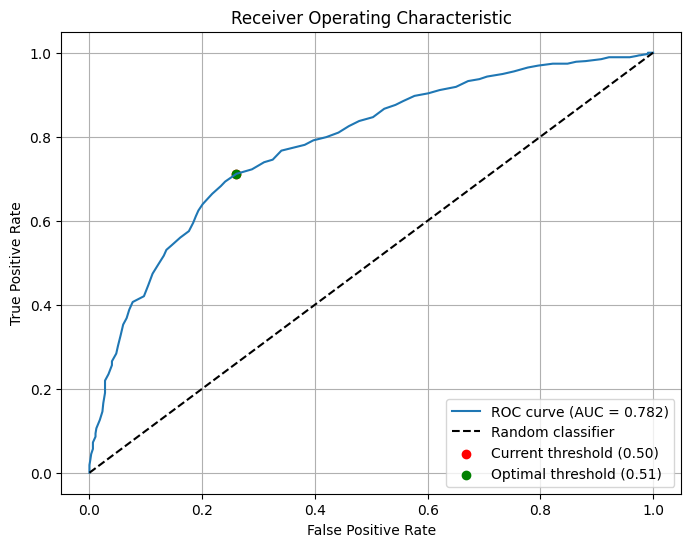

In [26]:
metrics.plot_roc()

In [27]:
X_reduced = X_df[['volatile acidity', 'residual sugar', 'free sulfur dioxide', 'sulphates', 'alcohol']]
X_reduced = scale.fit_transform(X_reduced)

X_red_train, X_red_test, Y_red_train, Y_red_test = train_test_split(X_reduced, Y, test_size = 0.2, random_state=42, stratify = Y)

In [22]:

model_reduced = LogRegression(alpha = 0.1, lambda_reg = 0, early_stopping = True, max_iter = 10000)
model_reduced.fit(X_red_train, Y_red_train)
model_reduced.summary(features_names =['volatile acidity', 'residual sugar', 'free sulfur dioxide', 'sulphates', 'alcohol'])
reduced_predictions = model_reduced.predict(X_red_test)
reduced_metrics = Metrics(Y_red_test, reduced_predictions)
print(f"Accuracy: {reduced_metrics.acc_score()}")
print(f"Confusion matrix: {reduced_metrics.conf_matrix()}")
print(f"AUC: {reduced_metrics.roc()}")


Summary:
Coefficients        Estimate   Std. Error          |z|     Pr(>|z|)
Intercept           -0.0129      0.0363     -0.3548      0.7227
volatile acidity     -0.6528      0.0442    -14.7542      0.0000
residual sugar       0.3210      0.0413      7.7788      0.0000
free sulfur dioxide      0.2112      0.0395      5.3519      0.0000
sulphates            0.1159      0.0369      3.1413      0.0017
alcohol              1.2833      0.0489     26.2325      0.0000
------------------------------------------------------------
AIC              -4597.3400
Accuracy: 0.7147239263803681
Confusion matrix: Precision: 0.7154, Recall: 0.7132, Specificity: 0.7163, F1 score: 0.7143
Confusion Matrix: 
 TP: 465,
 TN: 467,
 FP: 185,
 FN: 187
AUC: AUC: 0.7835


**Support Vector Machines**

In [23]:
linear_params_grid = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 10, 100, 1000],
        'early_stopping': [True],
        'max_iter': [1000, 5000, 10000]
    },
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 10, 100, 1000],
        'early_stopping': [False]

    }]
linear_results = GridSearch(X_train, Y_train, model_class = SupportVectorMachine, params_grid = linear_params_grid)
linear_results

{'Best parameters:': {'kernel': 'linear',
  'C': 10,
  'early_stopping': True,
  'max_iter': 10000},
 'Best accuracy:': 0.7147027893602782}

In [29]:
poly_params_grid =[
    {
        'kernel': ['polynomial'],
        'C': [0, 0.001, 0.01, 10, 100, 1000],
        'd' : [2, 3],
        'r':[0,1],
        'gamma': ['scale', 'auto', 0.001, 0.1, 1, 10],
        'early_stopping': [True],
        'max_iter': [1000, 5000, 10000]
    },
    {
        'kernel': ['polynomial'],
        'C': [0, 0.001, 0.01, 10, 100, 1000],
        'd' : [2, 3],
        'r':[0,1],
        'gamma': ['scale', 'auto', 0.001, 0.1, 1, 10],
        'early_stopping': [False]
    }]

poly_results = GridSearch(X_train, Y_train, model_class = SupportVectorMachine, params_grid = poly_params_grid)
poly_results

{'Best parameters:': {'kernel': 'polynomial',
  'C': 0,
  'd': 2,
  'r': 1,
  'gamma': 1,
  'early_stopping': True,
  'max_iter': 5000},
 'Best accuracy:': 0.7154701759804679}

In [30]:
radial_params_grid = [
    {
        'kernel': ['radial'],
        'C': [0, 0.001, 0.01, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.1, 1, 10],
        'early_stopping': [True],
        'max_iter': [1000, 5000, 10000]
    },
    {
        'kernel': ['radial'],
        'C': [0, 0.001, 0.01, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.1, 1, 10],
        'early_stopping': [False]
    }

]

rbf_results = GridSearch(X_train, Y_train, model_class = SupportVectorMachine, params_grid = radial_params_grid)
rbf_results

{'Best parameters:': {'kernel': 'radial',
  'C': 0,
  'gamma': 10,
  'early_stopping': False},
 'Best accuracy:': 0.8578238871607062}

In [31]:
svm_model = SupportVectorMachine(kernel = 'linear', C= 10, probability = True, early_stopping=True, max_iter =10000, verbose = False)
svm_model.fit(X_train, Y_train)
svm_model.summary()
predictions = svm_model.predict(X_test)
svm_metrics = Metrics(Y_test, predictions)
print(f"Accuracy: {svm_metrics.acc_score()}")
print(f"Confusion matrix: {svm_metrics.conf_matrix()}")
print(f"AUC: {svm_metrics.roc()}")

poly_model = SupportVectorMachine(kernel = 'polynomial', C= 0, d= 2, r =1,gamma =1, probability = True, early_stopping=True,  max_iter =5000, verbose = False)
poly_model.fit(X_train, Y_train)
poly_model.summary()
poly_predictions = poly_model.predict(X_test)
poly_metrics = Metrics(Y_test, poly_predictions)
print(f"Accuracy: {poly_metrics.acc_score()}")
print(f"Confusion matrix: {poly_metrics.conf_matrix()}")
print(f"AUC: {poly_metrics.roc()}")


rbf_model = SupportVectorMachine(kernel = 'radial', C= 0, gamma =10, probability = True, early_stopping=False, verbose = False)
rbf_model.fit(X_train, Y_train)
rbf_model.summary()
rbf_predictions = rbf_model.predict(X_test)
rbf_metrics = Metrics(Y_test, rbf_predictions)
print(f"Accuracy: {rbf_metrics.acc_score()}")
print(f"Confusion matrix: {rbf_metrics.conf_matrix()}")
print(f"AUC: {rbf_metrics.roc()}")

SVM Model Summary:
----------------------------------------
Kernel: linear
Regularization parameter (C): 10.0000
Number of support vectors: 2930
Weight vector shape: (11,)
Bias term: 0.0433
----------------------------------------
Accuracy: 0.7024539877300614
Confusion matrix: Precision: 0.7018, Recall: 0.7040, Specificity: 0.7009, F1 score: 0.7029
Confusion Matrix: 
 TP: 459,
 TN: 457,
 FP: 195,
 FN: 193
AUC: AUC: 0.7752
SVM Model Summary:
----------------------------------------
Kernel: polynomial
Regularization parameter (C): 0.0000
Gamma: 1.0000
Degree: 2
Coefficient: 1
Number of support vectors: 4165
Bias term: 0.0000
----------------------------------------
Accuracy: 0.7032208588957055
Confusion matrix: Precision: 0.7778, Recall: 0.5690, Specificity: 0.8374, F1 score: 0.6572
Confusion Matrix: 
 TP: 371,
 TN: 546,
 FP: 106,
 FN: 281
AUC: AUC: 0.6578
SVM Model Summary:
----------------------------------------
Kernel: radial
Regularization parameter (C): 0.0000
Gamma: 10.0000
Number

# Model evaluation on a different dataset

In [32]:
url2 = 'https://raw.githubusercontent.com/Valeria-Riccardo/statistical-learning/refs/heads/main/redwine.csv'
redwine = pd.read_csv(url2, sep = ';')
redwine['quality'] = np.where(redwine['quality']>5, 1, 0)
np.unique(redwine['quality'], return_counts = True)


(array([0, 1]), array([744, 855]))

In [33]:
X2 = redwine[['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates', 'alcohol']]
Y2 = redwine['quality']

X2 = scale.fit_transform(X2)

In [34]:
new_pred = model_reduced.predict(X2)
new_metrics = Metrics(Y2, new_pred)
print(f"Accuracy: {new_metrics.acc_score()}")
print(f"Confusion matrix: {new_metrics.conf_matrix()}")
print(f"AUC: {new_metrics.roc()}")

Accuracy: 0.699812382739212
Confusion matrix: Precision: 0.7652, Recall: 0.6327, Specificity: 0.7769, F1 score: 0.6927
Confusion Matrix: 
 TP: 541,
 TN: 578,
 FP: 166,
 FN: 314
AUC: AUC: 0.7758


In [36]:
X2_svm = redwine.drop(['quality'], axis =1)
Y2_svm = redwine['quality']
X2_svm = scale.fit_transform(X2_svm)

new_pred_svm = svm_model.predict(X2_svm)
new_metrics_svm = Metrics(Y2_svm, new_pred_svm)
print(f"Accuracy: {new_metrics_svm.acc_score()}")
print(f"Confusion matrix: {new_metrics_svm.conf_matrix()}")
print(f"AUC: {new_metrics_svm.roc()}")


new_pred_poly= poly_model.predict(X2_svm)
new_metrics_svm = Metrics(Y2_svm, new_pred_poly)
print(f"Accuracy: {new_metrics_svm.acc_score()}")
print(f"Confusion matrix: {new_metrics_svm.conf_matrix()}")
print(f"AUC: {new_metrics_svm.roc()}")


new_pred_rbf = rbf_model.predict(X2_svm)
new_metrics_svm = Metrics(Y2_svm, new_pred_rbf)
print(f"Accuracy: {new_metrics_svm.acc_score()}")
print(f"Confusion matrix: {new_metrics_svm.conf_matrix()}")
print(f"AUC: {new_metrics_svm.roc()}")

Accuracy: 0.7166979362101313
Confusion matrix: Precision: 0.7807, Recall: 0.6538, Specificity: 0.7890, F1 score: 0.7116
Confusion Matrix: 
 TP: 559,
 TN: 587,
 FP: 157,
 FN: 296
AUC: AUC: 0.7799
Accuracy: 0.6335209505941213
Confusion matrix: Precision: 0.8289, Recall: 0.3965, Specificity: 0.9059, F1 score: 0.5364
Confusion Matrix: 
 TP: 339,
 TN: 674,
 FP: 70,
 FN: 516
AUC: AUC: 0.6326
Accuracy: 0.6078799249530957
Confusion matrix: Precision: 0.6113, Recall: 0.7322, Specificity: 0.4651, F1 score: 0.6663
Confusion Matrix: 
 TP: 626,
 TN: 346,
 FP: 398,
 FN: 229
AUC: AUC: 0.5007
